In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [5]:
df = pd.read_csv('HR_comma_sep.csv')

In [6]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [8]:
df.isnull()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,False,False
14995,False,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [10]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [11]:
df.shape

(14999, 10)

In [12]:
df.left.value_counts()

,count
left,
0,11428
1,3571


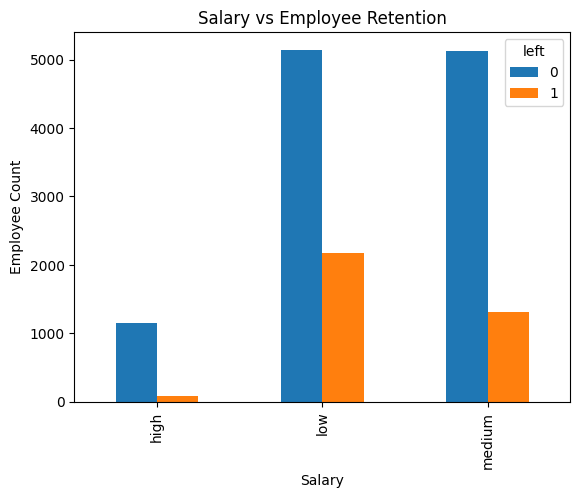

In [13]:
pd.crosstab(df.salary, df.left).plot(kind='bar')
plt.xlabel("Salary")
plt.ylabel("Employee Count")
plt.title("Salary vs Employee Retention")
plt.show()

In [15]:
subdf = df[['satisfaction_level',
            'average_montly_hours',
            'promotion_last_5years',
            'salary']]

In [16]:
salary_dummies = pd.get_dummies(df.salary, prefix='salary')
df_with_dummies = pd.concat([subdf, salary_dummies], axis='columns')
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [17]:
df_with_dummies.drop('salary', axis='columns', inplace=True)

In [18]:
X = df_with_dummies
y = df.left

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [24]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [26]:
model.score(X_test, y_test)

0.762

In [27]:
accuracy = model.score(X_test, y_test)
print("Accuracy (R² Score):", accuracy)

Accuracy (R² Score): 0.762


In [29]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.5 MB/s eta 0:00:00


In [30]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))
print(confusion_matrix(y_test, y_pred_cat))

CatBoost Accuracy: 0.9176666666666666
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      2294
           1       0.90      0.73      0.81       706

    accuracy                           0.92      3000
   macro avg       0.91      0.85      0.88      3000
weighted avg       0.92      0.92      0.91      3000

[[2238   56]
 [ 191  515]]


In [31]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))
print(confusion_matrix(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9053333333333333
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2294
           1       0.90      0.67      0.77       706

    accuracy                           0.91      3000
   macro avg       0.90      0.82      0.85      3000
weighted avg       0.91      0.91      0.90      3000

[[2244   50]
 [ 234  472]]
